In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import seaborn as sns

import re
from collections import Counter

In [7]:
COL_ACT0= "#5A99FF"
COL_ACT1= "#FF9B60"
COL_FB     = '#C44E52'
COL_LLAMA   = "#0011FF"
COL_QWEN   = "#FFAE00"

In [8]:
df_llama = pd.read_csv('logs/llm_policy/LLAMA/actions_log_LLAMA.csv')
df_qwen  = pd.read_csv('logs/llm_policy/QWEN/actions_log_QWEN.csv')

df_llama['model'] = 'LLaMA 3.2:3b'
df_qwen['model']  = 'Qwen3:4b'

ACTION_MAP = {'move_left': 0, 'move_right': 1}
for df in [df_llama, df_qwen]:
    df['action'] = df['action'].map(ACTION_MAP)

### Action choices distribution

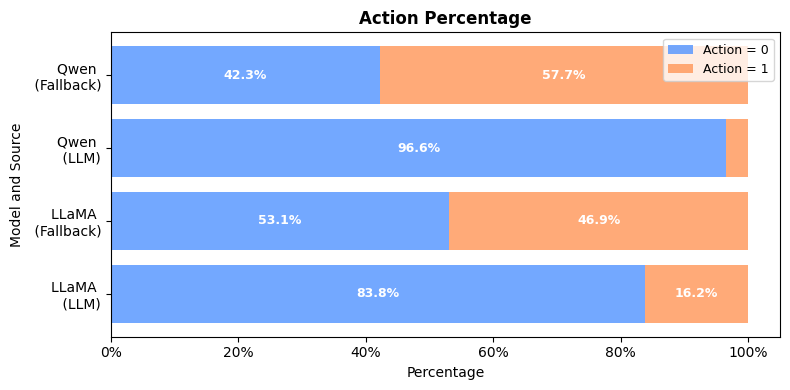

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

categories = [
    ('LLaMA \n (LLM)', df_llama[df_llama['source'] == 'llm']['action']),
    ('LLaMA \n (Fallback)', df_llama[df_llama['source'] == 'ppo_fallback']['action']),
    ('Qwen \n (LLM)', df_qwen[ df_qwen['source']  == 'llm']['action']),
    ('Qwen \n (Fallback)', df_qwen[ df_qwen['source']  == 'ppo_fallback']['action']),
]

labels, p0s, p1s = [], [], []
for lbl, s in categories:
    s = s.dropna()
    p1 = (s == 1).mean() if len(s) > 0 else 0
    labels.append(lbl)
    p0s.append(1 - p1)
    p1s.append(p1)

y = np.arange(len(labels))
ax.barh(y, p0s, color=COL_ACT0, alpha=0.85, label='Action = 0')
ax.barh(y, p1s, left=p0s, color=COL_ACT1, alpha=0.85, label='Action = 1')

for i, (p0, p1) in enumerate(zip(p0s, p1s)):
    if p0 > 0.05: ax.text(p0 / 2, i, f'{p0:.1%}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    if p1 > 0.05: ax.text(p0 + p1 / 2, i, f'{p1:.1%}', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('Percentage')
ax.set_ylabel('Model and Source')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Action Percentage', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('./logs/img/action_proportion_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

### LMMs responses analysis

In [10]:
def parse_tag(tag):
    SIDE_MAP = {'LEFT': 'LEFT', 'RIGH': 'RIGHT', 'CENT': 'CENT'}
    result = {'hit': 'NONE', 'act': 'NONE', 'np': 0, 'bullets': []}
    if pd.isna(tag):
        return result

    parts = [p.strip() for p in tag.split('|')]

    for part in parts:
        if part.startswith('HIT:'):
            result['hit'] = part[4:]
        elif part.startswith('ACT:'):
            result['act'] = part[4:]
        elif part.startswith('NP:'):
            try:
                result['np'] = int(part[3:])
            except ValueError:
                result['np'] = 0
        elif re.match(r'P\d+:', part):
            fields = part.split(':')[1].split(',')
            if len(fields) == 3:
                dist, side, direction = (f.strip() for f in fields)
                side = SIDE_MAP.get(side, side)
                result['bullets'].append((dist, side, direction))

    return result

def oracle(parsed):
    action = parsed['act']

    # 1. No projectiles : every action is correct
    if parsed['np'] == 0 or not parsed['bullets']:
        is_correct = action in ('LEFT', 'RIGHT')
        return is_correct

    concrete_threats = []
    for dist, side, direction in parsed['bullets']:
        if direction not in ('AWAY', 'PARA') and dist != 'DIST':
            concrete_threats.append((dist, side, direction))

    # 2. The threath is not concrete (AWAY/PARA or DIST): every action is correct
    if not concrete_threats:
        is_correct = action in ('LEFT', 'RIGHT')
        return is_correct

    # 3. Concrete threat (IMMI/APPR + TOWA):
    dist, side, direction = concrete_threats[0]
    if side == 'LEFT':
        is_correct = (action == "RIGHT")
        return is_correct
    elif side == 'RIGHT':
        is_correct = (action == "LEFT")
        return is_correct
    elif side == 'CENT':
        if action not in ('LEFT', 'RIGHT'):
            return False
        
        for next_bullet in concrete_threats[1:]:
            _, next_side, _ = next_bullet
            if next_side == 'LEFT':
                is_correct = (action == "RIGHT")
                return is_correct
            elif next_side == 'RIGHT':
                is_correct = (action == "LEFT")
                return is_correct 
        return True
    
    return (action in ('LEFT', 'RIGHT')) # Fallback


def apply_oracle(df):
    df = df.copy()

    parsed_col = df['tag'].apply(parse_tag)

    correct_col = []
    for p in parsed_col:
        verdict = oracle(p)
        correct_col.append(verdict)

    df['parsed'] = parsed_col
    df['correct_action'] = correct_col
    df['is_correct'] = df['correct_action'] == True

    return df

df_llama = apply_oracle(df_llama)
df_qwen  = apply_oracle(df_qwen)

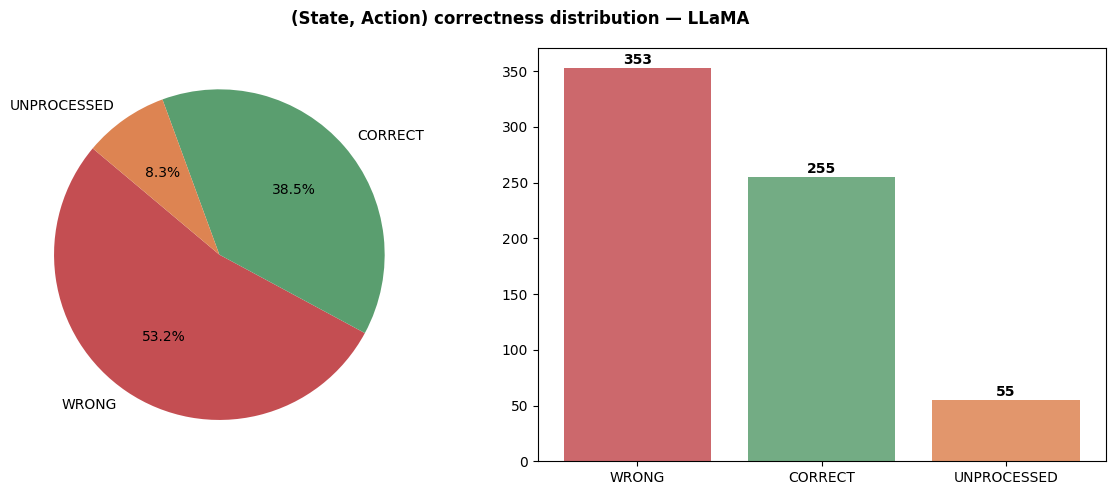

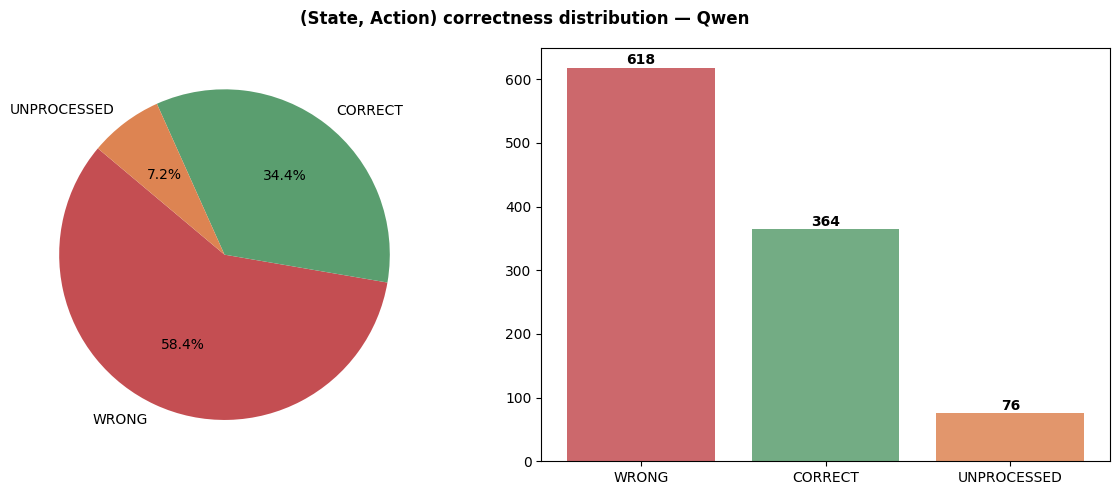

In [11]:
def build_state_taxonomy(df, label):
    rows = []

    for tag, group in df.groupby('tag'):
        llm_rows = group[group['source'] == 'llm']
        fb_rows = group[group['source'] == 'ppo_fallback']
        n_fb = len(fb_rows)

        # Feature strutturali del tag (costanti per lo stesso tag)
        parsed = group['parsed'].iloc[0]
        np_val = parsed['np']
        hit = parsed['hit']
        p1 = parsed['bullets'][0] if parsed['bullets'] else (None, None, None)
        p1_dist, p1_side, p1_dir = p1

        base = {
            'tag':          tag,
            'model':        label,
            'n_fallback':   n_fb,
            'np_val':       np_val,
            'hit':          hit,
            'p1_dist':      p1_dist,
            'p1_side':      p1_side,
            'p1_dir':       p1_dir,
        }

        if len(llm_rows) == 0:
            # State never processed by the llm (always under fallback)
            rows.append({**base,
                'status': 'UNPROCESSED',
                'llm_action': np.nan,
                'correct_action': np.nan,
            })
        else:
            llm_row = llm_rows.iloc[0]
            ca = llm_row['correct_action']
            action = llm_row['action']

            if llm_row['is_correct']:
                status = 'CORRECT'
            else:
                status = 'WRONG'

            rows.append({**base,
                'status': status,
                'llm_action': action,
                'correct_action': ca,
            })

    return pd.DataFrame(rows).set_index('tag')


def plot_taxonomy_overview(tax, label, title = None):
    counts = tax['status'].value_counts()
    status_colors = {
        'CORRECT': '#5A9E6F',
        'WRONG': '#C44E52',
        'UNPROCESSED': '#DD8452',
    }
    colors = [status_colors.get(s, '#333') for s in counts.index]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    if title is None:
        fig.suptitle(f'(State, Action) correctness distribution — {label}', fontweight='bold', fontsize=12)
    else:
        fig.suptitle(title, fontweight='bold', fontsize=12)

    # Pie
    wedges, texts, autotexts = axes[0].pie(
        counts.values,
        labels=counts.index,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        textprops={'fontsize': 10},
    )

    # Bar
    bars = axes[1].bar(counts.index, counts.values, color=colors, alpha=0.85)
    for bar, val in zip(bars, counts.values):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + len(tax)*0.005,
                     str(val), ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    fname = f'./logs/img/taxonomy_overview_{label.replace(" ","_").replace(":","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

tax_llama = build_state_taxonomy(df_llama, 'LLaMA')
tax_qwen  = build_state_taxonomy(df_qwen,  'Qwen')

for tax, lbl in [(tax_llama, 'LLaMA'), (tax_qwen, 'Qwen')]:
    plot_taxonomy_overview(tax, lbl)

In [12]:
def fallback_analysis(df, label, tax):
    df = df.copy()
    df['np_val'] = df['parsed'].apply(lambda p: p['np'])
    df['is_hit'] = df['parsed'].apply(lambda p: 1 if p['hit'] == 'HIT' else 0)

    fb  = df[df['source'] == 'ppo_fallback']
    tot = df.groupby('tag').agg(
        total_steps = ('action', 'count'),
        hit_rate = ('is_hit',  'mean'),
        np_mode = ('np_val',  lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    )
    fb_agg = fb.groupby('tag').agg(
        fallback_count = ('action', 'count'),
        dominant_fb_action = ('action', lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    )
    result = tot.join(fb_agg, how='left').fillna({'fallback_count': 0})
    result['fallback_rate'] = result['fallback_count'] / result['total_steps']
    result['model'] = label

    # Join con la tassonomia per aggiungere status e feature strutturali
    tax_cols = ['status', 'np_val', 'hit', 'p1_dist', 'p1_side', 'p1_dir']
    result = result.join(tax[tax_cols], how='left')

    return result.sort_values('fallback_rate', ascending=False)

fb_detail_llama = fallback_analysis(df_llama, 'LLaMA 3.2:3b', tax_llama)
fb_detail_qwen = fallback_analysis(df_qwen,  'Qwen3:4b',     tax_qwen)

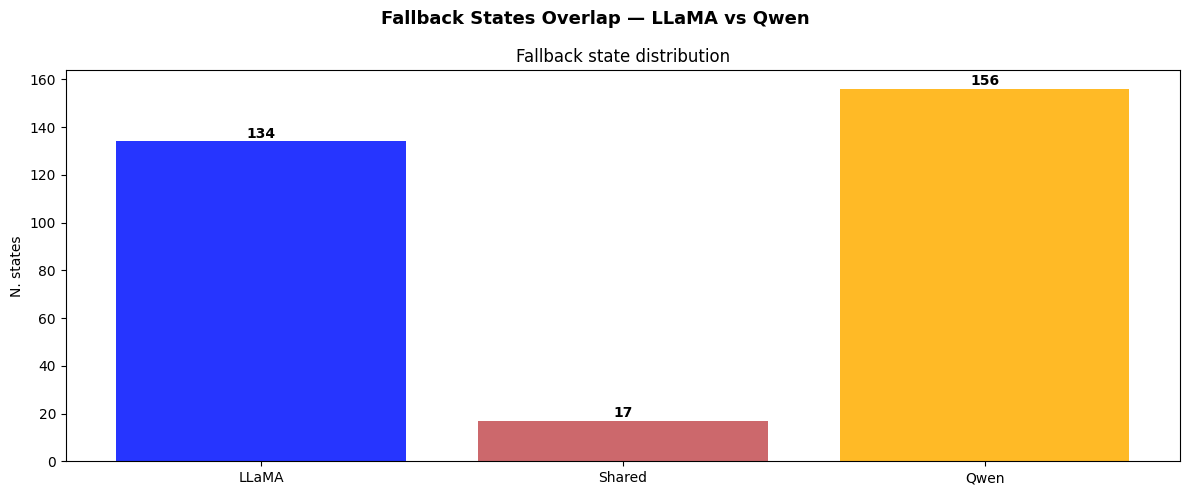

In [18]:
def plot_fallback_overlap(fb_llama, fb_qwen):
    fb_llama = fb_llama[fb_llama['fallback_rate'] > 0]
    fb_qwen  = fb_qwen[fb_qwen['fallback_rate']   > 0]

    states_llama = set(fb_llama.index)
    states_qwen  = set(fb_qwen.index)
    only_llama   = len(states_llama - states_qwen)
    only_qwen    = len(states_qwen  - states_llama)
    shared       = len(states_llama & states_qwen)

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle('Fallback States Overlap — LLaMA vs Qwen', fontweight='bold', fontsize=13)

    # Stacked bar
    categories = ['LLaMA', 'Shared', 'Qwen']
    values     = [only_llama, shared, only_qwen]
    colors     = [COL_LLAMA, COL_FB, COL_QWEN]
    bars = ax.bar(categories, values, color=colors, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.01,
                str(val), ha='center', fontsize=10, fontweight='bold',
                color='var(--color-text-primary)' if False else 'black')
    ax.set_ylabel('N. states')
    ax.set_title('Fallback state distribution')

    plt.tight_layout()
    plt.savefig('./logs/img/fallback_overlap.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_fallback_overlap(fb_detail_llama, fb_detail_qwen)

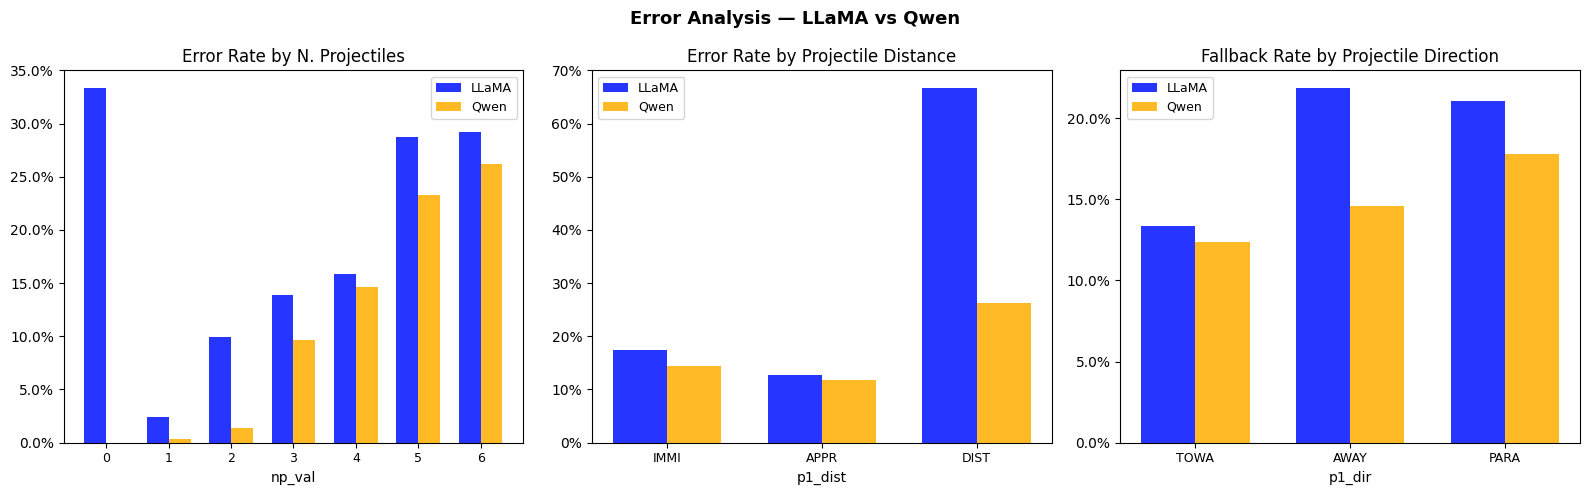

In [17]:
def plot_fallback_analysis(fb_llama, fb_qwen, title=None):
    fb_llama = fb_llama.loc[(fb_llama['fallback_rate'] > 0) | (fb_llama['status'] == 'WRONG')]
    fb_qwen = fb_qwen.loc[(fb_qwen['fallback_rate'] > 0) | (fb_qwen['status'] == 'WRONG')]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    if title:
        fig.suptitle(title, fontweight='bold', fontsize=13)
    else:
        fig.suptitle('Error Analysis — LLaMA vs Qwen', fontweight='bold', fontsize=13)

    w = 0.35

    #  Error rate by n projectiles
    ax = axes[0]
    llama_by_np = fb_llama.groupby('np_val')['fallback_rate'].mean()
    qwen_by_np  = fb_qwen.groupby('np_val')['fallback_rate'].mean()
    np_vals = sorted(set(llama_by_np.index) | set(qwen_by_np.index))
    x = np.arange(len(np_vals))
    ax.bar(x - w/2, [llama_by_np.get(n, 0) for n in np_vals], width=w, color=COL_LLAMA, alpha=0.85, label='LLaMA')
    ax.bar(x + w/2, [qwen_by_np.get(n, 0)  for n in np_vals], width=w, color=COL_QWEN,  alpha=0.85, label='Qwen')
    ax.set_xticks(x)
    ax.set_xticklabels([str(n) for n in np_vals], fontsize=9)
    ax.set_title('Error Rate by N. Projectiles')
    ax.set_xlabel('np_val')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(fontsize=9)

    # Error rate by rate by 1sr projectile distance
    ax = axes[1]
    dist_order = ['IMMI', 'APPR', 'DIST']
    llama_by_dist = fb_llama.groupby('p1_dist')['fallback_rate'].mean().reindex(dist_order)
    qwen_by_dist  = fb_qwen.groupby('p1_dist')['fallback_rate'].mean().reindex(dist_order)
    x = np.arange(len(dist_order))
    ax.bar(x - w/2, llama_by_dist, width=w, color=COL_LLAMA, alpha=0.85, label='LLaMA')
    ax.bar(x + w/2, qwen_by_dist,  width=w, color=COL_QWEN,  alpha=0.85, label='Qwen')
    ax.set_xticks(x)
    ax.set_xticklabels(dist_order, fontsize=9)
    ax.set_title('Error Rate by Projectile Distance')
    ax.set_xlabel('p1_dist')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(fontsize=9)

    # Error rate by 1st projectile direction vs action made
    ax = axes[2]
    dir_order = ['TOWA', 'AWAY', 'PARA']
    llama_by_dir = fb_llama.groupby('p1_dir')['fallback_rate'].mean().reindex(dir_order)
    qwen_by_dir  = fb_qwen.groupby('p1_dir')['fallback_rate'].mean().reindex(dir_order)
    x = np.arange(len(dir_order))
    ax.bar(x - w/2, llama_by_dir, width=w, color=COL_LLAMA, alpha=0.85, label='LLaMA')
    ax.bar(x + w/2, qwen_by_dir,  width=w, color=COL_QWEN,  alpha=0.85, label='Qwen')
    ax.set_xticks(x)
    ax.set_xticklabels(dir_order, fontsize=9)
    ax.set_title('Fallback Rate by Projectile Direction')
    ax.set_xlabel('p1_dir')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('./logs/img/fallback_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_fallback_analysis(fb_detail_llama, fb_detail_qwen)